# Singular Value Decomposition (SVD)

### From the basics to low-rank approximation — a quant interview survival guide

Welcome! This notebook builds **SVD** from the ground up. By the end you'll understand:

1. **The basics** — what SVD *is* and the beautiful geometric picture behind it (rotate → stretch → rotate).
2. **SVD ↔ EVD** — how SVD relates to the eigenvalue decomposition you already know.
3. **The Moore–Penrose pseudo-inverse** — how to "invert" any matrix, even non-square or singular ones (this is what least-squares regression secretly uses).
4. **Range & null space** — reading the four fundamental subspaces of a matrix straight off its SVD.
5. **Truncated SVD** — the single most important matrix tool in data science: optimal low-rank approximation (PCA, compression, denoising, recommender systems).

> **Why a quant should care:** SVD is *everywhere* in quant finance — PCA on yield curves and factor models, denoising noisy covariance matrices, solving over-determined regressions stably, and dimensionality reduction. It is one of the **most frequently tested linear-algebra topics in quant interviews**. You will see 🎯 markers throughout flagging the parts interviewers love to probe.

---"

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

np.set_printoptions(precision=3, suppress=True)  # cleaner matrix printing
rng = np.random.default_rng(0)                    # reproducible randomness

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

# Our consistent color palette
PALETTE = ["steelblue", "tomato", "mediumseagreen", "darkorange", "navy"]
print("Setup complete. NumPy version:", np.__version__)

Setup complete. NumPy version: 2.4.6


## 1 · The Basics — What Is SVD?

**Why this matters first:** every matrix you'll ever meet — square or rectangular, full-rank or degenerate, real data or random noise — has an SVD. It's the one factorization that *never fails*. That universality is what makes it the Swiss-army knife of linear algebra.

### The big idea

A matrix $\mathbf{A}$ is a function: it takes a vector $\mathbf{x}$ and maps it to a new vector $\mathbf{A}\mathbf{x}$. SVD says that **any** such linear map, no matter how complicated it looks, is really just three simple operations performed one after another:

$$\mathbf{A} \;=\; \mathbf{U}\,\boldsymbol{\Sigma}\,\mathbf{V}^{\top}$$

Read right-to-left (because that's the order they act on $\mathbf{x}$):

| Step | Matrix | Geometric action | Analogy |
|------|--------|------------------|---------|
| 1 | $\mathbf{V}^{\top}$ | **Rotate / reflect** (no stretching) | Spin the input so it lines up with the "natural" axes |
| 2 | $\boldsymbol{\Sigma}$ | **Stretch** each axis by a factor $\sigma_i \ge 0$ | Pull/squash along those axes |
| 3 | $\mathbf{U}$ | **Rotate / reflect** again | Spin the stretched result into its final orientation |

> **Key insight:** Every linear map = **rotation → stretch → rotation**. There is no fourth kind of thing a matrix can do. SVD finds the special pair of orthonormal axes (input axes in $\mathbf{V}$, output axes in $\mathbf{U}$) for which the messy map becomes pure stretching.

### The pieces (notation table)

| Symbol | Shape ($\mathbf{A}$ is $m\times n$) | Meaning |
|--------|------|---------|
| $\mathbf{U}$ | $m\times m$ | **Left singular vectors**. Orthonormal: $\mathbf{U}^{\top}\mathbf{U}=\mathbf{I}$. The output axes. |
| $\boldsymbol{\Sigma}$ | $m\times n$ | Diagonal-ish. The **singular values** $\sigma_1\ge\sigma_2\ge\dots\ge 0$ on the diagonal. The stretch factors. |
| $\mathbf{V}$ | $n\times n$ | **Right singular vectors**. Orthonormal: $\mathbf{V}^{\top}\mathbf{V}=\mathbf{I}$. The input axes. |

A few facts to lock in:

- **Singular values are non-negative and sorted** $\sigma_1 \ge \sigma_2 \ge \cdots \ge 0$. The biggest one, $\sigma_1$, is the maximum stretch the matrix can apply to any unit vector — it equals the **spectral norm** $\lVert \mathbf{A}\rVert_2$. 🎯
- $\mathbf{U}$ and $\mathbf{V}$ being **orthonormal** means they only rotate/reflect — they never change lengths. All the size-changing lives in $\boldsymbol{\Sigma}$.
- The number of **non-zero** singular values equals the **rank** of $\mathbf{A}$. 🎯

---"

In [2]:
# --- Compute an SVD and verify the three pieces ---
A = np.array([[3.0, 1.0],
              [0.0, 2.0]])

# np.linalg.svd returns U, the vector of singular values s, and V^T (already transposed!)
U, s, Vt = np.linalg.svd(A)
Sigma = np.diag(s)

print("A =\n", A)
print("\nU (left singular vectors, columns) =\n", U)
print("\nsingular values s =", s)
print("\nV^T (rows are right singular vectors) =\n", Vt)

# Reconstruct A and confirm
A_reconstructed = U @ Sigma @ Vt
print("\nU @ Sigma @ V^T =\n", A_reconstructed)
print("\nReconstruction matches A? ", np.allclose(A, A_reconstructed))

# Confirm orthonormality (U^T U = I and V^T V = I)
print("\nU is orthonormal? ", np.allclose(U.T @ U, np.eye(2)))
print("V is orthonormal? ", np.allclose(Vt @ Vt.T, np.eye(2)))

# sigma_1 == spectral norm == largest stretch
print("\nsigma_1 =", s[0], " vs np.linalg.norm(A, 2) =", np.linalg.norm(A, 2))

A =
 [[3. 1.]
 [0. 2.]]

U (left singular vectors, columns) =
 [[ 0.957 -0.29 ]
 [ 0.29   0.957]]

singular values s = [3.257 1.842]

V^T (rows are right singular vectors) =
 [[ 0.882  0.472]
 [-0.472  0.882]]

U @ Sigma @ V^T =
 [[ 3.  1.]
 [-0.  2.]]

Reconstruction matches A?  True

U is orthonormal?  True
V is orthonormal?  True

sigma_1 = 3.25661653798294  vs np.linalg.norm(A, 2) = 3.2566165379829393


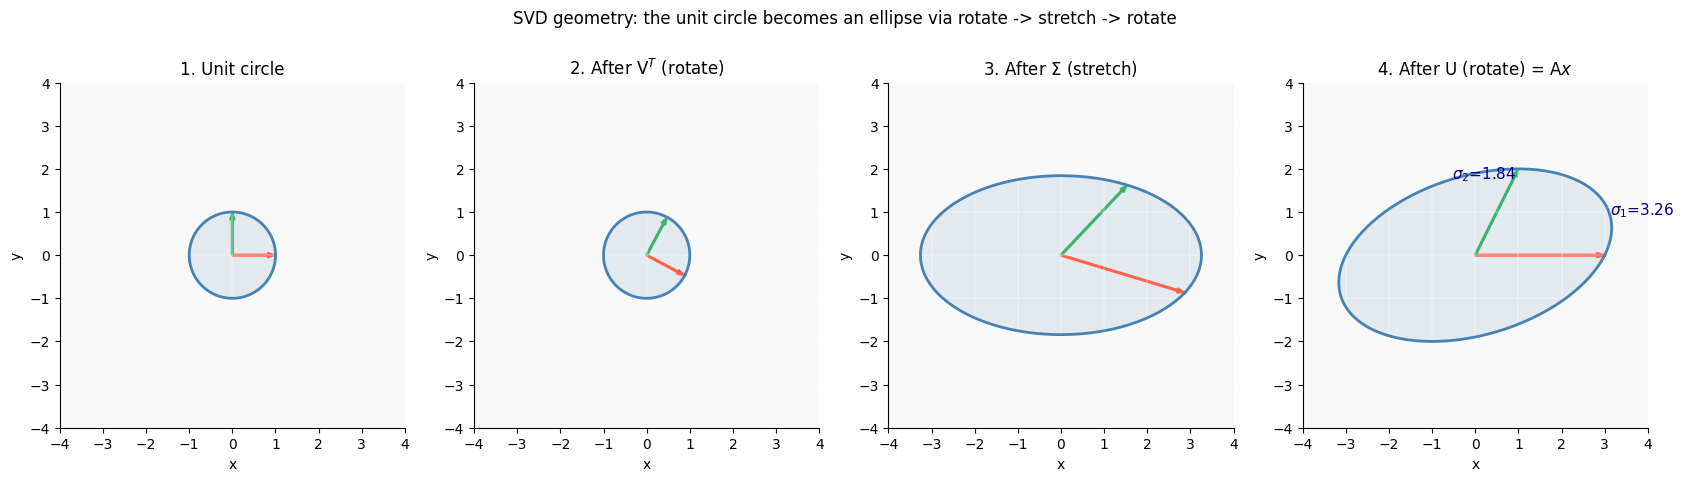

Ellipse semi-axis lengths = singular values = [3.257 1.842]
Ellipse axis directions   = columns of U =
 [[ 0.957 -0.29 ]
 [ 0.29   0.957]]


In [3]:
# --- Visualize "rotate -> stretch -> rotate" on the unit circle ---
# A linear map sends the unit circle to an ELLIPSE. The ellipse's axis directions
# are the columns of U, and its axis half-lengths are the singular values sigma_i.

theta = np.linspace(0, 2 * np.pi, 200)
circle = np.vstack([np.cos(theta), np.sin(theta)])   # unit circle, shape (2, 200)
e1, e2 = np.array([1, 0]), np.array([0, 1])           # standard basis to track

fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
stages = [
    ("1. Unit circle",            circle,                e1, e2),
    ("2. After V$^T$ (rotate)",   Vt @ circle,           Vt @ e1, Vt @ e2),
    ("3. After $\\Sigma$ (stretch)", Sigma @ Vt @ circle,   Sigma @ Vt @ e1, Sigma @ Vt @ e2),
    ("4. After U (rotate) = A$x$", A @ circle,            A @ e1, A @ e2),
]

for ax, (title, pts, v1, v2) in zip(axes, stages):
    ax.plot(pts[0], pts[1], color="steelblue", lw=2)
    ax.fill(pts[0], pts[1], color="steelblue", alpha=0.12)
    ax.arrow(0, 0, v1[0], v1[1], color="tomato", width=0.04, length_includes_head=True)
    ax.arrow(0, 0, v2[0], v2[1], color="mediumseagreen", width=0.04, length_includes_head=True)
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)

# Mark the singular-value axes on the final ellipse
axes[-1].annotate(f"$\\sigma_1$={s[0]:.2f}", xy=U[:, 0] * s[0], color="navy", fontsize=11)
axes[-1].annotate(f"$\\sigma_2$={s[1]:.2f}", xy=U[:, 1] * s[1], color="navy", fontsize=11)

plt.suptitle("SVD geometry: the unit circle becomes an ellipse via rotate -> stretch -> rotate", y=1.04)
plt.tight_layout()
plt.show()

print("Ellipse semi-axis lengths = singular values =", s)
print("Ellipse axis directions   = columns of U =\n", U)

## 2 · SVD ↔ EVD — The Connection

**Why this matters:** you already know the **eigenvalue decomposition (EVD)** $\mathbf{A} = \mathbf{Q}\boldsymbol{\Lambda}\mathbf{Q}^{-1}$. But EVD only works for *square* matrices, and is only "nice" (orthogonal $\mathbf{Q}$, real $\lambda$) for *symmetric* ones. SVD is what you get when you apply EVD's nicest case to the symmetric matrices $\mathbf{A}^{\top}\mathbf{A}$ and $\mathbf{A}\mathbf{A}^{\top}$ that you can build from *any* matrix. Understanding this link is a **classic interview question**. 🎯

### Deriving the link step by step

Start from the SVD $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top}$ and form the two symmetric matrices you can always build:

**Right side — $\mathbf{A}^{\top}\mathbf{A}$ (an $n\times n$ matrix):**

$$\mathbf{A}^{\top}\mathbf{A} = (\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top})^{\top}(\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top}) = \mathbf{V}\boldsymbol{\Sigma}^{\top}\underbrace{\mathbf{U}^{\top}\mathbf{U}}_{=\,\mathbf{I}}\boldsymbol{\Sigma}\mathbf{V}^{\top} = \mathbf{V}\,(\boldsymbol{\Sigma}^{\top}\boldsymbol{\Sigma})\,\mathbf{V}^{\top}$$

The middle term $\boldsymbol{\Sigma}^{\top}\boldsymbol{\Sigma}$ is diagonal with entries $\sigma_i^2$. Compare this to the EVD of the symmetric matrix $\mathbf{A}^{\top}\mathbf{A} = \mathbf{Q}\boldsymbol{\Lambda}\mathbf{Q}^{\top}$. Term by term:

> **The right singular vectors $\mathbf{V}$ are the eigenvectors of $\mathbf{A}^{\top}\mathbf{A}$, and the eigenvalues are $\lambda_i = \sigma_i^2$.**

**Left side — $\mathbf{A}\mathbf{A}^{\top}$ (an $m\times m$ matrix):** by the identical argument,

$$\mathbf{A}\mathbf{A}^{\top} = \mathbf{U}\,(\boldsymbol{\Sigma}\boldsymbol{\Sigma}^{\top})\,\mathbf{U}^{\top}$$

> **The left singular vectors $\mathbf{U}$ are the eigenvectors of $\mathbf{A}\mathbf{A}^{\top}$, with the same eigenvalues $\sigma_i^2$.**

### The recipe (this is how you'd compute SVD by hand in an interview) 🎯

$$\boxed{\;\sigma_i = \sqrt{\lambda_i(\mathbf{A}^{\top}\mathbf{A})}\;}\qquad \mathbf{v}_i = \text{eigvecs of }\mathbf{A}^{\top}\mathbf{A}, \qquad \mathbf{u}_i = \frac{1}{\sigma_i}\mathbf{A}\mathbf{v}_i$$

That last identity $\mathbf{A}\mathbf{v}_i = \sigma_i \mathbf{u}_i$ is the heart of SVD: **each right singular vector, when fed through $\mathbf{A}$, lands on the corresponding left singular vector, scaled by $\sigma_i$.** Since $\mathbf{A}^{\top}\mathbf{A}$ is symmetric positive *semi*-definite, its eigenvalues are $\ge 0$, so the square root is always real — that's *why* singular values are always real and non-negative.

> **Special case worth memorizing:** if $\mathbf{A}$ is **symmetric positive semi-definite**, then its SVD and EVD coincide: $\sigma_i = \lambda_i$ and $\mathbf{u}_i = \mathbf{v}_i$. For a general symmetric matrix with a negative eigenvalue $\lambda_i<0$, you get $\sigma_i = |\lambda_i|$ and the sign is absorbed by flipping $\mathbf{u}_i = -\mathbf{v}_i$. 🎯

---"

In [4]:
# --- Build SVD FROM SCRATCH using the EVD of A^T A (the by-hand recipe) ---
def svd_from_evd(A):
    """Compute a (thin-ish) SVD using only an eigensolver on A^T A."""
    n = A.shape[1]
    # 1. Eigendecompose the symmetric PSD matrix A^T A
    eigvals, eigvecs = np.linalg.eigh(A.T @ A)   # eigh -> ascending order, orthonormal vecs
    # 2. Sort descending so the biggest singular value comes first
    order = np.argsort(eigvals)[::-1]
    eigvals, V = eigvals[order], eigvecs[:, order]
    # 3. Singular values are sqrt of (clipped) eigenvalues
    sigmas = np.sqrt(np.clip(eigvals, 0, None))
    # 4. Left singular vectors: u_i = (1/sigma_i) A v_i  (only where sigma_i > 0)
    U = np.zeros((A.shape[0], len(sigmas)))
    for i, sig in enumerate(sigmas):
        if sig > 1e-12:
            U[:, i] = (A @ V[:, i]) / sig
    return U, sigmas, V.T

U2, s2, Vt2 = svd_from_evd(A)
print("From-scratch singular values:", s2)
print("NumPy     singular values:", s)
print("\nReconstruct A from scratch:\n", U2 @ np.diag(s2) @ Vt2)
print("\nMatches A? ", np.allclose(U2 @ np.diag(s2) @ Vt2, A))

# Verify the core identity A v_i = sigma_i u_i for each i
print("\nChecking  A v_i = sigma_i u_i  for each singular triple:")
for i in range(len(s2)):
    print(f"  i={i}: ||A v_i - sigma_i u_i|| = {np.linalg.norm(A @ Vt2[i] - s2[i] * U2[:, i]):.2e}")

From-scratch singular values: [3.257 1.842]
NumPy     singular values: [3.257 1.842]

Reconstruct A from scratch:
 [[3. 1.]
 [0. 2.]]

Matches A?  True

Checking  A v_i = sigma_i u_i  for each singular triple:
  i=0: ||A v_i - sigma_i u_i|| = 1.11e-16
  i=1: ||A v_i - sigma_i u_i|| = 0.00e+00


## 3 · Range & Null Space — Reading the Four Fundamental Subspaces

**Why this matters:** SVD doesn't just factor a matrix — it hands you an *orthonormal basis* for every subspace associated with it. Questions like "what's the rank?", "is this system solvable?", "what's the null space?" all become trivial once you have the SVD. Interviewers love this because it ties together rank, range, null space, and orthogonality in one object. 🎯

### First, the rank-1 sum view (super important)

Multiplying out $\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top}$ gives a sum of simple **rank-1 building blocks**:

$$\mathbf{A} = \sum_{i=1}^{r} \sigma_i\, \mathbf{u}_i \mathbf{v}_i^{\top}, \qquad r = \text{rank}(\mathbf{A})$$

Each term $\sigma_i \mathbf{u}_i \mathbf{v}_i^{\top}$ is an outer product — a rank-1 matrix — weighted by its importance $\sigma_i$. Think of it like a **recipe**: $\mathbf{A}$ is a weighted blend of ingredients, and the singular values tell you how much of each ingredient to use. The first term (largest $\sigma_1$) captures the dominant pattern; later terms add finer detail. This single equation is the engine behind truncated SVD in Section 5.

### The four fundamental subspaces, straight from SVD

Let $r$ = number of non-zero singular values = rank. Split $\mathbf{U}$ and $\mathbf{V}$ into "active" columns (first $r$) and "silent" columns (the rest):

| Subspace | What it is | Orthonormal basis | Dimension |
|----------|-----------|-------------------|-----------|
| **Column space** $\;\mathcal{R}(\mathbf{A})$ | all possible outputs $\mathbf{A}\mathbf{x}$ | $\mathbf{u}_1,\dots,\mathbf{u}_r$ (active left vecs) | $r$ |
| **Null space** $\;\mathcal{N}(\mathbf{A})$ | inputs crushed to zero: $\mathbf{A}\mathbf{x}=\mathbf{0}$ | $\mathbf{v}_{r+1},\dots,\mathbf{v}_n$ (silent right vecs) | $n-r$ |
| **Row space** $\;\mathcal{R}(\mathbf{A}^{\top})$ | all $\mathbf{A}^{\top}\mathbf{y}$ | $\mathbf{v}_1,\dots,\mathbf{v}_r$ (active right vecs) | $r$ |
| **Left null space** $\;\mathcal{N}(\mathbf{A}^{\top})$ | $\mathbf{A}^{\top}\mathbf{y}=\mathbf{0}$ | $\mathbf{u}_{r+1},\dots,\mathbf{u}_m$ (silent left vecs) | $m-r$ |

> **Key insight:** A singular vector with $\sigma_i > 0$ is "alive" — it carries signal into the output. A direction with $\sigma_i = 0$ is "dead" — feed it in and it vanishes. The null space is *exactly* the span of those dead input directions. This is why **rank = number of non-zero singular values**: it's the count of directions that survive the map.

The **Rank–Nullity theorem** falls out for free: $\underbrace{r}_{\dim \mathcal{R}} + \underbrace{(n-r)}_{\dim \mathcal{N}} = n$. 🎯

---"

In [5]:
# --- A deliberately RANK-DEFICIENT matrix so the null space is non-trivial ---
# Column 3 = column 1 + column 2  => the columns are linearly dependent => rank 2.
B = np.array([[1.0, 0.0, 1.0],
              [0.0, 1.0, 1.0],
              [1.0, 1.0, 2.0],
              [2.0, 1.0, 3.0]])   # 4x3 matrix

Ub, sb, Vtb = np.linalg.svd(B)
tol = 1e-10
r = int(np.sum(sb > tol))          # rank = number of non-zero singular values
print("singular values of B:", sb)
print("numerical rank r =", r, " (np.linalg.matrix_rank =", np.linalg.matrix_rank(B), ")")

# Bases for the four subspaces, read directly off U and V
col_space   = Ub[:, :r]            # active left singular vectors
left_null   = Ub[:, r:]            # silent left singular vectors
row_space   = Vtb[:r, :].T         # active right singular vectors
null_space  = Vtb[r:, :].T         # silent right singular vectors

print("\nNull space basis (columns) — directions B sends to zero:\n", null_space)

# PROOF that these are null directions: B @ (null vector) should be ~0
for j in range(null_space.shape[1]):
    v = null_space[:, j]
    print(f"  ||B @ null_vec_{j}|| = {np.linalg.norm(B @ v):.2e}  (should be ~0)")

# Rank-nullity check
print(f"\nRank-Nullity:  r={r} + nullity={null_space.shape[1]} = {r + null_space.shape[1]} = n={B.shape[1]}")

# Rank-1 reconstruction check: sum of sigma_i u_i v_i^T rebuilds B
B_rebuilt = sum(sb[i] * np.outer(Ub[:, i], Vtb[i]) for i in range(r))
print("\nRebuilt B from", r, "rank-1 terms matches B?", np.allclose(B_rebuilt, B))

singular values of B: [4.777 1.088 0.   ]
numerical rank r = 2  (np.linalg.matrix_rank = 2 )

Null space basis (columns) — directions B sends to zero:
 [[-0.577]
 [-0.577]
 [ 0.577]]
  ||B @ null_vec_0|| = 5.44e-16  (should be ~0)

Rank-Nullity:  r=2 + nullity=1 = 3 = n=3

Rebuilt B from 2 rank-1 terms matches B? True


## 4 · The Moore–Penrose Pseudo-Inverse

**Why this matters:** you can only invert a square, full-rank matrix. But in the real world matrices are usually rectangular (more data rows than parameters) or rank-deficient. The **pseudo-inverse** $\mathbf{A}^{+}$ is the "best possible" stand-in for an inverse that works for *any* matrix — and it's exactly what `np.linalg.lstsq` and ordinary least-squares regression use under the hood. **Extremely common in quant interviews** because linear regression is the bread-and-butter of factor modelling. 🎯

### Building it from SVD

The genius of SVD: to "undo" a matrix, just undo each of its three steps in reverse. $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top}$ does *rotate→stretch→rotate*, so its inverse should *un-rotate→un-stretch→un-rotate*:

$$\boxed{\;\mathbf{A}^{+} = \mathbf{V}\,\boldsymbol{\Sigma}^{+}\,\mathbf{U}^{\top}\;}$$

Un-rotating is easy — orthogonal matrices invert by transposing ($\mathbf{U}^{-1}=\mathbf{U}^{\top}$). The only subtlety is **un-stretching** $\boldsymbol{\Sigma}^{+}$:

$$\sigma_i \;\longrightarrow\; \sigma_i^{+} = \begin{cases} \dfrac{1}{\sigma_i} & \sigma_i > 0 \quad(\text{reciprocal: undo the stretch})\\[2mm] 0 & \sigma_i = 0 \quad(\text{can't undo a crush — leave it at }0) \end{cases}$$

> **Key insight:** You can't recover information that was destroyed. A direction stretched by $\sigma_i$ is un-stretched by $1/\sigma_i$. But a direction *crushed to zero* ($\sigma_i = 0$) is gone forever — so the pseudo-inverse wisely maps it back to $0$ instead of dividing by zero. That single rule is what lets $\mathbf{A}^{+}$ exist for every matrix.

### What problem does it actually solve?

For the linear system $\mathbf{A}\mathbf{x} = \mathbf{b}$, the pseudo-inverse solution $\hat{\mathbf{x}} = \mathbf{A}^{+}\mathbf{b}$ is special in two ways:

- **Overdetermined / no exact solution** (tall $\mathbf{A}$, e.g. regression): it returns the **least-squares** solution — the $\mathbf{x}$ minimizing $\lVert \mathbf{A}\mathbf{x} - \mathbf{b}\rVert_2$. This is *literally* the normal-equations answer $\hat{\mathbf{x}} = (\mathbf{A}^{\top}\mathbf{A})^{-1}\mathbf{A}^{\top}\mathbf{b}$, but computed stably via SVD instead of inverting $\mathbf{A}^{\top}\mathbf{A}$. 🎯
- **Underdetermined / many solutions** (wide $\mathbf{A}$): it returns the solution with the **smallest norm** $\lVert\mathbf{x}\rVert_2$ — the most parsimonious one.

> **Interview gotcha:** the normal-equations form $(\mathbf{A}^{\top}\mathbf{A})^{-1}\mathbf{A}^{\top}$ *squares the condition number* and blows up when columns are collinear. The SVD-based pseudo-inverse is the numerically stable way to do the same regression — and it still works (returning the min-norm solution) even when $\mathbf{A}^{\top}\mathbf{A}$ is singular. 🎯

---"

beta via from-scratch pseudo-inverse: [1.677 1.546]
beta via normal equations         : [1.677 1.546]
beta via np.linalg.lstsq          : [1.677 1.546]

Our pinv matches np.linalg.pinv?   True


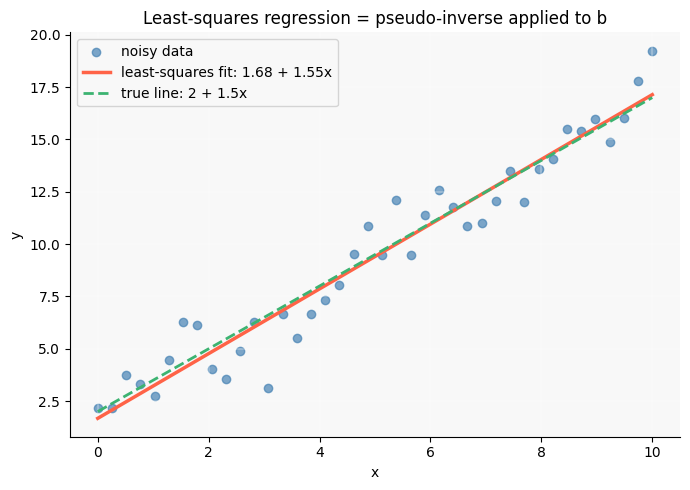

In [6]:
# --- Pseudo-inverse from scratch, then use it for least-squares regression ---
def pinv_from_svd(A, tol=1e-12):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    s_plus = np.array([1.0 / si if si > tol else 0.0 for si in s])  # reciprocal, except zeros
    return Vt.T @ np.diag(s_plus) @ U.T

# Build a noisy linear regression: y = 2 + 1.5*x + noise  (tall design matrix => overdetermined)
x = np.linspace(0, 10, 40)
y_true = 2.0 + 1.5 * x
y = y_true + rng.normal(0, 1.5, size=x.shape)
X = np.column_stack([np.ones_like(x), x])   # design matrix [1, x], shape (40, 2)

# Three ways to get the SAME least-squares fit:
beta_pinv   = pinv_from_svd(X) @ y                         # our from-scratch pseudo-inverse
beta_normal = np.linalg.inv(X.T @ X) @ X.T @ y            # textbook normal equations
beta_lstsq  = np.linalg.lstsq(X, y, rcond=None)[0]        # NumPy's stable solver

print("beta via from-scratch pseudo-inverse:", beta_pinv)
print("beta via normal equations         :", beta_normal)
print("beta via np.linalg.lstsq          :", beta_lstsq)
print("\nOur pinv matches np.linalg.pinv?  ", np.allclose(pinv_from_svd(X), np.linalg.pinv(X)))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color="steelblue", alpha=0.7, label="noisy data")
ax.plot(x, X @ beta_pinv, color="tomato", lw=2.5, label=f"least-squares fit: {beta_pinv[0]:.2f} + {beta_pinv[1]:.2f}x")
ax.plot(x, y_true, color="mediumseagreen", lw=2, ls="--", label="true line: 2 + 1.5x")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Least-squares regression = pseudo-inverse applied to b")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5 · Truncated SVD — Optimal Low-Rank Approximation

**Why this matters:** this is the payoff. Real data matrices (prices, returns, images, user-item ratings) are huge but *mostly redundant* — their information lives in a few dominant directions. Truncated SVD lets you keep only the top $k$ singular components and throw away the rest, giving the **best possible rank-$k$ approximation** of your matrix. This is the mathematical core of **PCA, image compression, denoising, and recommender systems**. If you understand one application of SVD for a quant interview, make it this one. 🎯

### The idea: keep the big ingredients, drop the small ones

Recall the rank-1 sum $\mathbf{A} = \sum_{i=1}^{r} \sigma_i \mathbf{u}_i \mathbf{v}_i^{\top}$. Since the $\sigma_i$ are sorted big-to-small, just **stop early** after $k$ terms:

$$\mathbf{A}_k = \sum_{i=1}^{k} \sigma_i\, \mathbf{u}_i \mathbf{v}_i^{\top}, \qquad k < r$$

You're keeping the $k$ strongest patterns and discarding the faint ones (which are often just noise).

### The Eckart–Young–Mirsky theorem (the headline result) 🎯

$\mathbf{A}_k$ isn't just *a* good rank-$k$ approximation — it's provably the **best one possible**, for both the spectral and Frobenius norms:

$$\mathbf{A}_k = \arg\min_{\text{rank}(\mathbf{M}) \le k} \lVert \mathbf{A} - \mathbf{M} \rVert$$

and the leftover error is given *exactly* by the singular values you threw away:

$$\lVert \mathbf{A} - \mathbf{A}_k \rVert_2 = \sigma_{k+1}, \qquad \lVert \mathbf{A} - \mathbf{A}_k \rVert_F = \sqrt{\sigma_{k+1}^2 + \cdots + \sigma_{r}^2}$$

> **Key insight:** No other rank-$k$ matrix — built any way you like — can get closer to $\mathbf{A}$ than $\mathbf{A}_k$ does. The error is simply the energy of the dropped singular values. So the **decay of the singular value spectrum** tells you how compressible your data is: a fast drop means a few components capture almost everything.

### The compression win

Storing the full $m\times n$ matrix costs $mn$ numbers. Storing the rank-$k$ truncation costs only the $k$ singular values plus their vectors: $k(m + n + 1)$ numbers. When $k \ll \min(m,n)$, that's a massive saving.

> **Quant connection:** the **"explained variance ratio"** $\sum_{i\le k}\sigma_i^2 / \sum_i \sigma_i^2$ is exactly the PCA scree-plot quantity — how interviewers ask "how many factors explain the yield curve / the return covariance?" The answer is "look at where the singular values fall off a cliff." 🎯

---"

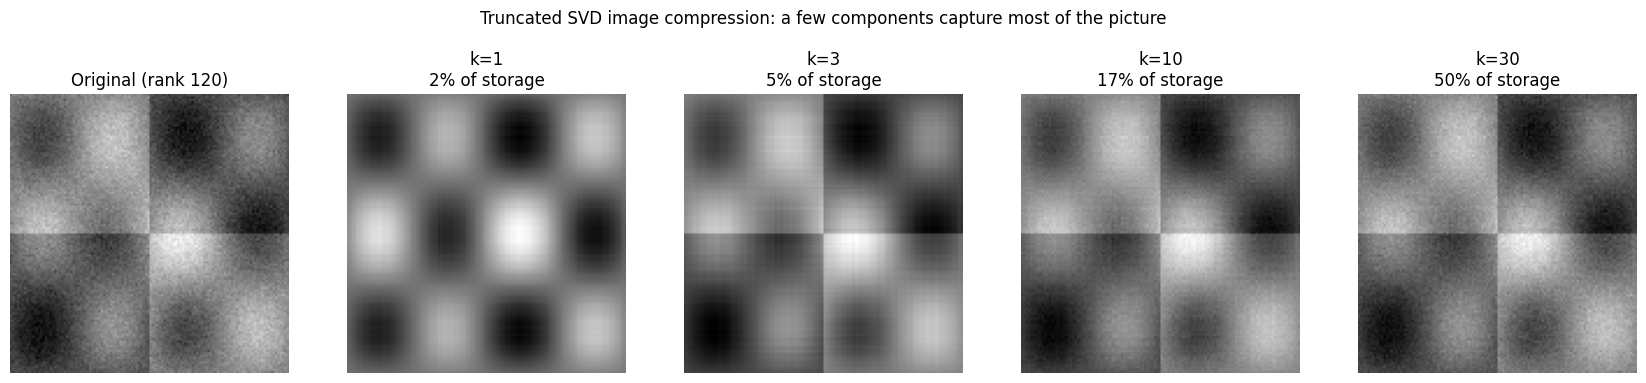

In [7]:
# --- Build a synthetic "image" (a matrix of pixel intensities) with rich structure ---
N = 120
xs = np.linspace(-3, 3, N)
XX, YY = np.meshgrid(xs, xs)
img = (np.sin(XX * 2) * np.cos(YY * 1.5)          # smooth wave pattern (low-rank-ish)
       + np.exp(-(XX**2 + YY**2) / 2)              # central blob
       + 0.4 * np.sign(XX) * np.sign(YY))         # sharp checkerboard edges (needs high rank)
img += 0.15 * rng.standard_normal((N, N))         # a sprinkle of noise

# Truncated SVD: keep the top-k singular components
def truncated_svd(A, k):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return (U[:, :k] * s[:k]) @ Vt[:k, :]         # == sum_{i<k} s_i u_i v_i^T

U_img, s_img, Vt_img = np.linalg.svd(img, full_matrices=False)

# Compare the original to several rank-k reconstructions
ks = [1, 3, 10, 30]
fig, axes = plt.subplots(1, len(ks) + 1, figsize=(17, 3.6))
axes[0].imshow(img, cmap="gray"); axes[0].set_title(f"Original (rank {len(s_img)})")
axes[0].axis("off")
for ax, k in zip(axes[1:], ks):
    approx = truncated_svd(img, k)
    storage = k * (img.shape[0] + img.shape[1] + 1)
    pct = 100 * storage / img.size
    ax.imshow(approx, cmap="gray")
    ax.set_title(f"k={k}\n{pct:.0f}% of storage")
    ax.axis("off")
plt.suptitle("Truncated SVD image compression: a few components capture most of the picture", y=1.05)
plt.tight_layout(); plt.show()

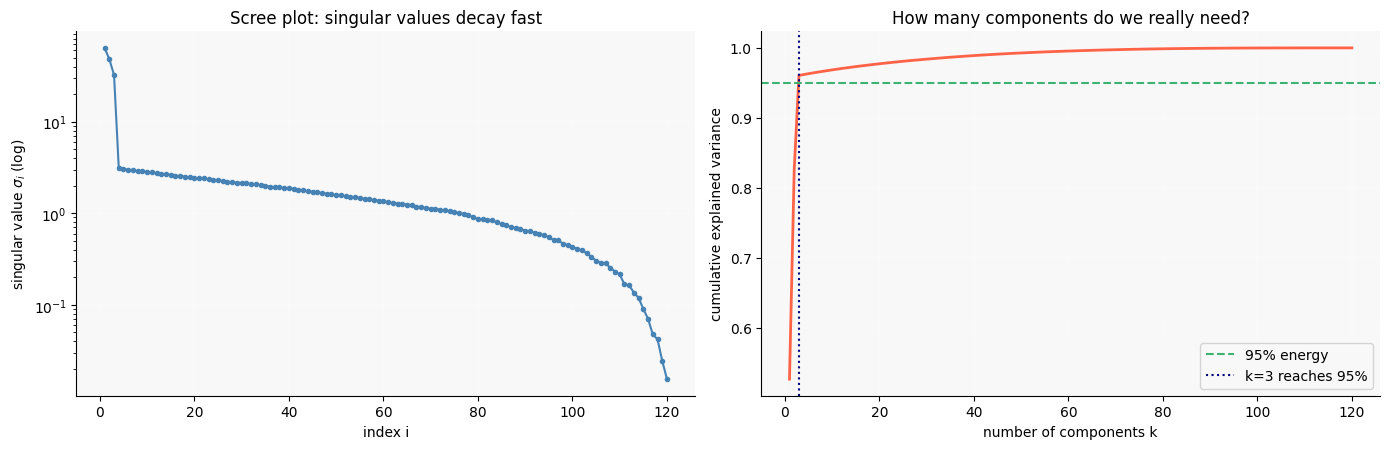

Just 3 of 120 components capture 95% of the energy.

Eckart-Young verification (the truncation error equals the dropped singular values):
  k= 1:  spectral 48.2406 vs sigma_(k+1) 48.2406 | frobenius 60.6771 vs tail-norm 60.6771
  k= 5:  spectral 2.9880 vs sigma_(k+1) 2.9880 | frobenius 16.9390 vs tail-norm 16.9390
  k=20:  spectral 2.4130 vs sigma_(k+1) 2.4130 | frobenius 13.2915 vs tail-norm 13.2915


In [8]:
# --- The singular-value spectrum + verifying Eckart-Young exactly ---
energy = s_img**2
cum_explained = np.cumsum(energy) / energy.sum()   # PCA-style explained-variance ratio

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6))

# Left: scree plot (log scale) — watch for the "cliff"
ax1.semilogy(np.arange(1, len(s_img) + 1), s_img, color="steelblue", marker="o", ms=3)
ax1.set_xlabel("index i"); ax1.set_ylabel("singular value $\\sigma_i$ (log)")
ax1.set_title("Scree plot: singular values decay fast")
ax1.grid(alpha=0.3)

# Right: cumulative explained variance
ax2.plot(np.arange(1, len(s_img) + 1), cum_explained, color="tomato", lw=2)
ax2.axhline(0.95, color="mediumseagreen", ls="--", label="95% energy")
k95 = int(np.argmax(cum_explained >= 0.95)) + 1
ax2.axvline(k95, color="navy", ls=":", label=f"k={k95} reaches 95%")
ax2.set_xlabel("number of components k"); ax2.set_ylabel("cumulative explained variance")
ax2.set_title("How many components do we really need?")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Just {k95} of {len(s_img)} components capture 95% of the energy.")

# Eckart-Young check: actual error == sigma_{k+1} (spectral) and tail-norm (Frobenius)
print("\nEckart-Young verification (the truncation error equals the dropped singular values):")
for k in [1, 5, 20]:
    Ak = truncated_svd(img, k)
    spec_err = np.linalg.norm(img - Ak, 2)
    frob_err = np.linalg.norm(img - Ak, "fro")
    spec_pred = s_img[k]                              # sigma_{k+1} (0-indexed)
    frob_pred = np.sqrt(np.sum(s_img[k:]**2))
    print(f"  k={k:2d}:  spectral {spec_err:.4f} vs sigma_(k+1) {spec_pred:.4f} | "
          f"frobenius {frob_err:.4f} vs tail-norm {frob_pred:.4f}")

## 6 · Bonus — SVD *is* PCA (the quant's favourite application)

**Why this matters:** quant interviewers rarely ask "explain SVD" in the abstract. They ask "how do you find the factors driving a basket of returns?" or "how do you reduce the dimensionality of a covariance matrix?" — and the honest answer is **SVD**. PCA is just SVD applied to mean-centered data. 🎯

### The link in one line

Take a data matrix $\mathbf{X}$ ($m$ samples $\times$ $n$ features) and **center it** (subtract the column means). The sample covariance is $\mathbf{C} = \frac{1}{m-1}\mathbf{X}^{\top}\mathbf{X}$. From Section 2 we know the eigenvectors of $\mathbf{X}^{\top}\mathbf{X}$ are the **right singular vectors $\mathbf{V}$**. Therefore:

$$\underbrace{\mathbf{V}}_{\text{right sing. vecs}} = \text{principal component directions}, \qquad \underbrace{\frac{\sigma_i^2}{m-1}}_{\text{from sing. values}} = \text{variance explained by PC } i$$

> **Key insight:** You never need to form the covariance matrix to do PCA. Running SVD directly on the centered data is more numerically stable (it avoids squaring the condition number — same lesson as the pseudo-inverse). The principal components are the right singular vectors; the variances are the singular values squared. **Truncated SVD = keeping the top few factors.** 🎯

The code below confirms that SVD on centered data reproduces `sklearn`'s PCA exactly.

---"

Variance explained (SVD)    : [4.389 0.088]
Variance explained (sklearn): [4.389 0.088]

PC directions match (up to sign)? True


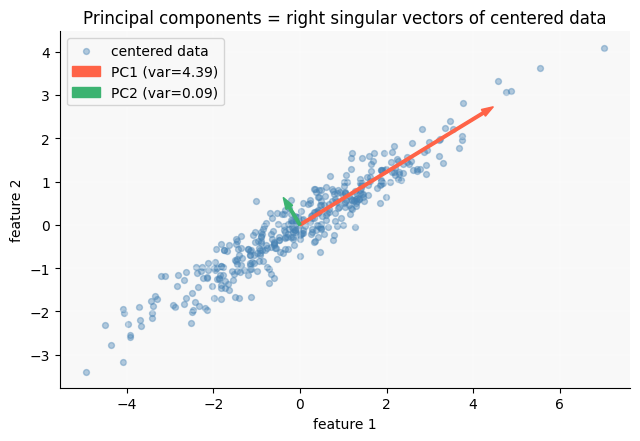

In [9]:
# --- SVD on centered data == PCA (verified against scikit-learn) ---
from sklearn.decomposition import PCA

# Correlated 2D data (think: two correlated assets' returns)
mean = [0, 0]
cov  = [[3.0, 1.8], [1.8, 1.2]]
data = rng.multivariate_normal(mean, cov, size=400)
data_c = data - data.mean(axis=0)            # center the columns

# PCA via SVD
Ud, sd, Vtd = np.linalg.svd(data_c, full_matrices=False)
var_svd = sd**2 / (len(data_c) - 1)          # variance explained by each component

# PCA via sklearn
pca = PCA(n_components=2).fit(data_c)

print("Variance explained (SVD)    :", var_svd)
print("Variance explained (sklearn):", pca.explained_variance_)
print("\nPC directions match (up to sign)?",
      np.allclose(np.abs(Vtd), np.abs(pca.components_)))

# Visualize the principal axes scaled by their standard deviation
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(data_c[:, 0], data_c[:, 1], color="steelblue", alpha=0.4, s=18, label="centered data")
for i, color in zip(range(2), ["tomato", "mediumseagreen"]):
    direction = Vtd[i] * np.sqrt(var_svd[i]) * 2.5    # scale arrow by sqrt(variance)
    ax.arrow(0, 0, direction[0], direction[1], color=color, width=0.06,
             length_includes_head=True, label=f"PC{i+1} (var={var_svd[i]:.2f})", zorder=5)
ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
ax.set_title("Principal components = right singular vectors of centered data")
ax.set_aspect("equal"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7 · Summary & Interview Cheat-Sheet

You made it! Here's everything in one place.

### Concept summary

| Concept | Key Idea |
|---------|----------|
| **SVD** | Every matrix factors as $\mathbf{A}=\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top}$ = rotate → stretch → rotate. Always exists. |
| **Singular values** | The stretch factors $\sigma_1\ge\dots\ge0$. $\sigma_1=\lVert\mathbf{A}\rVert_2$; number of non-zero ones = rank. |
| **$\mathbf{U}$, $\mathbf{V}$** | Orthonormal bases (output / input axes). $\mathbf{A}\mathbf{v}_i=\sigma_i\mathbf{u}_i$. |
| **SVD ↔ EVD** | $\mathbf{V}$ = eigvecs of $\mathbf{A}^{\top}\mathbf{A}$, $\mathbf{U}$ = eigvecs of $\mathbf{A}\mathbf{A}^{\top}$, $\sigma_i=\sqrt{\lambda_i}$. |
| **Pseudo-inverse** | $\mathbf{A}^{+}=\mathbf{V}\boldsymbol{\Sigma}^{+}\mathbf{U}^{\top}$; invert non-zero $\sigma_i\to1/\sigma_i$, leave zeros at 0. Gives least-squares / min-norm solution. |
| **Range** | Column space = span of $\mathbf{u}_i$ with $\sigma_i>0$. Dim = rank. |
| **Null space** | Span of $\mathbf{v}_i$ with $\sigma_i=0$ — the directions $\mathbf{A}$ crushes to zero. Dim = $n-r$. |
| **Truncated SVD** | $\mathbf{A}_k=\sum_{i\le k}\sigma_i\mathbf{u}_i\mathbf{v}_i^{\top}$ is the *optimal* rank-$k$ approximation (Eckart–Young). |
| **Approx. error** | $\lVert\mathbf{A}-\mathbf{A}_k\rVert_2=\sigma_{k+1}$; $\lVert\mathbf{A}-\mathbf{A}_k\rVert_F=\sqrt{\sum_{i>k}\sigma_i^2}$. |
| **PCA** | SVD of centered data: $\mathbf{V}$ = principal directions, $\sigma_i^2/(m-1)$ = variances. |

### 🎯 Rapid-fire interview Q&A

- **"What's the rank of a matrix from its SVD?"** → count the non-zero singular values.
- **"What is $\sigma_1$?"** → the spectral norm $\lVert\mathbf{A}\rVert_2$, the max stretch on any unit vector.
- **"Relate SVD and eigendecomposition."** → SVD = EVD of $\mathbf{A}^{\top}\mathbf{A}$ / $\mathbf{A}\mathbf{A}^{\top}$; $\sigma_i=\sqrt{\lambda_i}$; they coincide for symmetric PSD matrices.
- **"Why use SVD for regression instead of the normal equations?"** → numerical stability; normal equations square the condition number and fail on collinear columns. SVD handles rank-deficiency gracefully.
- **"How do you pick the number of PCA factors?"** → cumulative explained variance $\sum_{i\le k}\sigma_i^2/\sum_i\sigma_i^2$; look for the elbow / cliff in the scree plot.
- **"Best rank-$k$ approximation?"** → truncate the SVD (Eckart–Young), error = dropped singular values.
- **"Are singular values ever negative or complex?"** → never. They're $\sqrt{}$ of eigenvalues of a PSD matrix, so always real and $\ge 0$.

> **Final takeaway:** if you remember one sentence — *"SVD turns any matrix into rotate-stretch-rotate, and the singular values rank every direction by importance"* — every other property follows from it. Good luck in the interview! 🚀"